# TinyNeRF

In [12]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import json
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

CONFIG = {
    "seed": 42,
    "near": 2.0,
    "far": 6.0,
    "batch_size": 1024,
    "learning_rate": 5e-4,
    "num_epochs": 100,
    "num_samples": 64,  # single-pass sampling for baseline
    "position_frequencies": 6,
    "hidden_width": 128,
    "retrain": False,  # Set to True to force retraining even if checkpoint exists
}
os.makedirs('weights', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)


Using device: cuda


## Dataset Loading

In [13]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float()
poses = torch.from_numpy(data['poses']).float()
focal = float(data['focal'])
H, W = images.shape[1:3]
K = torch.tensor([[focal, 0, W/2.0], [0, focal, H/2.0], [0, 0, 1]], dtype=torch.float32).to(device)
print(f"Dataset: Images shape={images.shape}, Poses shape={poses.shape}")

Dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4])


## Train/Test Split

In [14]:
test_images, test_poses = images[100:], poses[100:]
train_images, train_poses = images[:100], poses[:100]
print(f"Training: {train_images.shape}, Test: {test_images.shape}")

Training: torch.Size([100, 100, 100, 3]), Test: torch.Size([6, 100, 100, 3])


## Ray Generation

In [15]:
def get_rays(K, c2w, H, W):
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1],
        -torch.ones_like(i)
    ], dim=-1)
    rays_d = dirs @ c2w[:3, :3].T
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

## NeRF Dataset and DataLoader

In [16]:
class NeRFDataset(torch.utils.data.Dataset):
    def __init__(self, images, poses, intrinsic):
        self.images, self.poses, self.intrinsic = images, poses, intrinsic
        self.H, self.W = images.shape[1], images.shape[2]
        self.all_rays_o, self.all_rays_d, self.all_rays_rgbs = [], [], []
        for i in range(len(images)):
            rays_o, rays_d = get_rays(self.intrinsic, self.poses[i].to(device), self.H, self.W)
            self.all_rays_o.append(rays_o.reshape(-1, 3).cpu())
            self.all_rays_d.append(rays_d.reshape(-1, 3).cpu())
            self.all_rays_rgbs.append(images[i].reshape(-1, 3))
        self.all_rays_o = torch.cat(self.all_rays_o, dim=0)
        self.all_rays_d = torch.cat(self.all_rays_d, dim=0)
        self.all_rays_rgbs = torch.cat(self.all_rays_rgbs, dim=0)

    def __len__(self):
        return len(self.all_rays_o)

    def __getitem__(self, idx):
        return (self.all_rays_o[idx], self.all_rays_d[idx], self.all_rays_rgbs[idx])

train_dataloader = torch.utils.data.DataLoader(
    NeRFDataset(train_images, train_poses, K),
    batch_size=CONFIG['batch_size'], shuffle=True
)

## Positional Encoding (with buffer registration)

In [17]:
class PositionalEncoding(nn.Module):
    def __init__(self, L_embed=6):
        super().__init__()
        self.L_embed = L_embed
        self.register_buffer(
            'bands',
            (2.0 ** torch.arange(L_embed, dtype=torch.float32) * torch.pi).view(1, L_embed, 1)
        )

    def forward(self, x):
        x_scaled = x.unsqueeze(-2) * self.bands
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2)
        sin_cos = sin_cos.flatten(start_dim=-2)
        encoded = torch.cat([x, sin_cos], dim=-1)
        return encoded

## Baseline Tiny NeRF Model (position-only)

KEY difference from Extended. NO direction input. Both density AND color come from position only.

In [18]:
class TinyNeRF(nn.Module):
    """Baseline: position-only NeRF. No view direction conditioning."""
    def __init__(self, filter_size=128, L_embed=6):
        super().__init__()
        self.positional_encoding = PositionalEncoding(L_embed)
        x_dim = 3 + 3 * 2 * L_embed  # 39 for L_embed=6
        self.layer1 = nn.Linear(x_dim, filter_size)
        self.layer2 = nn.Linear(filter_size, filter_size)
        self.output_layer = nn.Linear(filter_size, 4)  # sigma + rgb

    def forward(self, x):
        x_encoded = self.positional_encoding(x)
        h = F.relu(self.layer1(x_encoded))
        h = F.relu(self.layer2(h))
        out = self.output_layer(h)
        sigma = F.relu(out[..., :1])
        rgb = torch.sigmoid(out[..., 1:4])
        return torch.cat([sigma, rgb], dim=-1)

## Volume Rendering

In [19]:
def volume_rendering(sigma, rgb, t_vals):
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    dist_shape = list(deltas.shape[:-1]) + [1]
    last_dist = torch.full(dist_shape, 1e10, device=sigma.device)
    deltas = torch.cat([deltas, last_dist], dim=-1)
    alpha = 1.0 - torch.exp(-sigma * deltas)
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]
    weights = alpha * T
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2)
    return rgb_map, weights

## Single-pass renderer for baseline

In [20]:
def render_rays_baseline(model, rays_o, rays_d, near, far, N_samples, rand=False):
    original_shape = rays_o.shape[:-1]
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)
    num_rays = rays_o_flat.shape[0]
    
    # Stratified sampling
    t_vals = torch.linspace(near, far, N_samples, device=rays_o.device, dtype=rays_o.dtype)
    t_vals = t_vals.expand(num_rays, N_samples)
    
    if rand:
        mids = 0.5 * (t_vals[..., 1:] + t_vals[..., :-1])
        upper = torch.cat([mids, t_vals[..., -1:]], dim=-1)
        lower = torch.cat([t_vals[..., :1], mids], dim=-1)
        t_rand = torch.rand_like(t_vals)
        t_vals = lower + (upper - lower) * t_rand
    
    # Compute 3D points
    points = rays_o_flat[:, None, :] + rays_d_flat[:, None, :] * t_vals[..., None]
    
    # Forward pass (position only for baseline)
    raw = model(points.reshape(-1, 3))
    raw = raw.reshape(num_rays, N_samples, 4)
    
    sigma = raw[..., 0]
    rgb = raw[..., 1:4]
    
    rgb_map, weights = volume_rendering(sigma, rgb, t_vals)
    rgb_map = rgb_map.reshape(*original_shape, 3)
    return rgb_map

## Chunked image rendering

In [21]:
def render_image_baseline(model, rays_o, rays_d, chunk_size=4096, **render_kwargs):
    H, W = rays_o.shape[0], rays_o.shape[1]
    rays_o_flat = rays_o.reshape(-1, 3)
    rays_d_flat = rays_d.reshape(-1, 3)
    rgb_chunks = []
    for i in range(0, rays_o_flat.shape[0], chunk_size):
        chunk_o = rays_o_flat[i:i+chunk_size]
        chunk_d = rays_d_flat[i:i+chunk_size]
        rgb_chunk = render_rays_baseline(model, chunk_o, chunk_d, **render_kwargs)
        rgb_chunks.append(rgb_chunk)
    rgb_map = torch.cat(rgb_chunks, dim=0)
    return rgb_map.reshape(H, W, 3)

## Training

Skips retraining if checkpoint `weights/tiny_nerf_best.pth` already exists.
To retrain from scratch, set `CONFIG['retrain'] = True` or `RETRAIN = True` in the cell below.

In [22]:
model = TinyNeRF(filter_size=CONFIG['hidden_width'], L_embed=CONFIG['position_frequencies']).to(device)
optimizer = optim.Adam(model.parameters(), lr=CONFIG['learning_rate'])

N_samples = CONFIG['num_samples']
near, far = CONFIG['near'], CONFIG['far']
N_epochs = CONFIG['num_epochs']

train_psnrs = []
test_psnrs = []
train_losses = []
best_test_psnr = 0.0
start_time = time.time()

print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# Set RETRAIN = True to force retraining even if weights exist
RETRAIN = CONFIG.get('retrain', False)
weights_path = 'weights/tiny_nerf_best.pth'

if os.path.exists(weights_path) and not RETRAIN:
    print(f"Found existing checkpoint at '{weights_path}'. Skipping training.")
    print("Set CONFIG['retrain'] = True or RETRAIN = True to force retraining.")
    try:
        checkpoint = torch.load(weights_path, map_location=device, weights_only=False)
    except TypeError:
        checkpoint = torch.load(weights_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    train_psnrs = checkpoint.get('train_psnrs', [])
    test_psnrs = checkpoint.get('test_psnrs', [])
    train_losses = checkpoint.get('train_losses', [])
    total_time = checkpoint.get('total_training_time', 0.0)
    best_test_psnr = max(test_psnrs) if test_psnrs else 0.0
    print(f"Loaded checkpoint (epoch {checkpoint.get('epoch', 'N/A')}, best test PSNR: {best_test_psnr:.2f} dB, training time: {total_time:.1f}s).")
else:
    for epoch in range(N_epochs):
        model.train()
        sse = 0.0
        num_values = 0
        epoch_loss = 0.0
        batch_count = 0
        
        for rays_o, rays_d, rays_rgb in train_dataloader:
            rays_o = rays_o.to(device, non_blocking=True)
            rays_d = rays_d.to(device, non_blocking=True)
            rays_rgb = rays_rgb.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            rgb_pred = render_rays_baseline(model, rays_o, rays_d, near=near, far=far, N_samples=N_samples, rand=True)
            loss = F.mse_loss(rgb_pred, rays_rgb)
            loss.backward()
            optimizer.step()
            
            sse += F.mse_loss(rgb_pred, rays_rgb, reduction='sum').item()
            num_values += rays_rgb.numel()
            epoch_loss += loss.item()
            batch_count += 1
        
        epoch_mse = sse / num_values
        epoch_psnr = -10.0 * np.log10(epoch_mse)
        train_psnrs.append(float(epoch_psnr))
        train_losses.append(float(epoch_loss / batch_count))
        
        # Test evaluation every 10 epochs or last epoch
        if (epoch + 1) % 10 == 0 or epoch == N_epochs - 1:
            model.eval()
            with torch.inference_mode():
                avg_test_psnr = 0.0
                for test_idx in range(len(test_images)):
                    testimg = test_images[test_idx].to(device)
                    testpose = test_poses[test_idx].to(device)
                    rays_o, rays_d = get_rays(K, testpose, H, W)
                    rgb = render_image_baseline(model, rays_o, rays_d, near=near, far=far, N_samples=N_samples, rand=False)
                    test_mse = F.mse_loss(rgb, testimg).item()
                    psnr = -10.0 * np.log10(test_mse)
                    avg_test_psnr += psnr
                avg_test_psnr /= len(test_images)
                test_psnrs.append(float(avg_test_psnr))
                
                if avg_test_psnr > best_test_psnr:
                    best_test_psnr = avg_test_psnr
                    torch.save({
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'epoch': epoch,
                        'config': CONFIG,
                        'train_psnrs': [float(x) for x in train_psnrs],
                        'test_psnrs': [float(x) for x in test_psnrs],
                        'train_losses': [float(x) for x in train_losses],
                        'total_training_time': float(time.time() - start_time),
                    }, 'weights/tiny_nerf_best.pth')
                
                print(f"Epoch {epoch+1}/{N_epochs} | Train PSNR: {epoch_psnr:.2f} | Test PSNR: {avg_test_psnr:.2f} | Best: {best_test_psnr:.2f}")
        else:
            print(f"Epoch {epoch+1}/{N_epochs} | Train PSNR: {epoch_psnr:.2f}")

    total_time = time.time() - start_time
    print(f"Training complete in {total_time:.1f}s")
    print(f"Best test PSNR: {best_test_psnr:.2f} dB")


Model parameters: 22148
Epoch 1/100 | Train PSNR: 15.23
Epoch 2/100 | Train PSNR: 20.78
Epoch 3/100 | Train PSNR: 21.54
Epoch 4/100 | Train PSNR: 22.05
Epoch 5/100 | Train PSNR: 22.40
Epoch 6/100 | Train PSNR: 22.66
Epoch 7/100 | Train PSNR: 22.87
Epoch 8/100 | Train PSNR: 23.03
Epoch 9/100 | Train PSNR: 23.16
Epoch 10/100 | Train PSNR: 23.27 | Test PSNR: 24.23 | Best: 24.23
Epoch 11/100 | Train PSNR: 23.37
Epoch 12/100 | Train PSNR: 23.43
Epoch 13/100 | Train PSNR: 23.50
Epoch 14/100 | Train PSNR: 23.56
Epoch 15/100 | Train PSNR: 23.61
Epoch 16/100 | Train PSNR: 23.67
Epoch 17/100 | Train PSNR: 23.70
Epoch 18/100 | Train PSNR: 23.74
Epoch 19/100 | Train PSNR: 23.77
Epoch 20/100 | Train PSNR: 23.82 | Test PSNR: 24.73 | Best: 24.73
Epoch 21/100 | Train PSNR: 23.85
Epoch 22/100 | Train PSNR: 23.89
Epoch 23/100 | Train PSNR: 23.91
Epoch 24/100 | Train PSNR: 23.94
Epoch 25/100 | Train PSNR: 23.98
Epoch 26/100 | Train PSNR: 24.01
Epoch 27/100 | Train PSNR: 24.02
Epoch 28/100 | Train PSNR: 2

## Evaluation

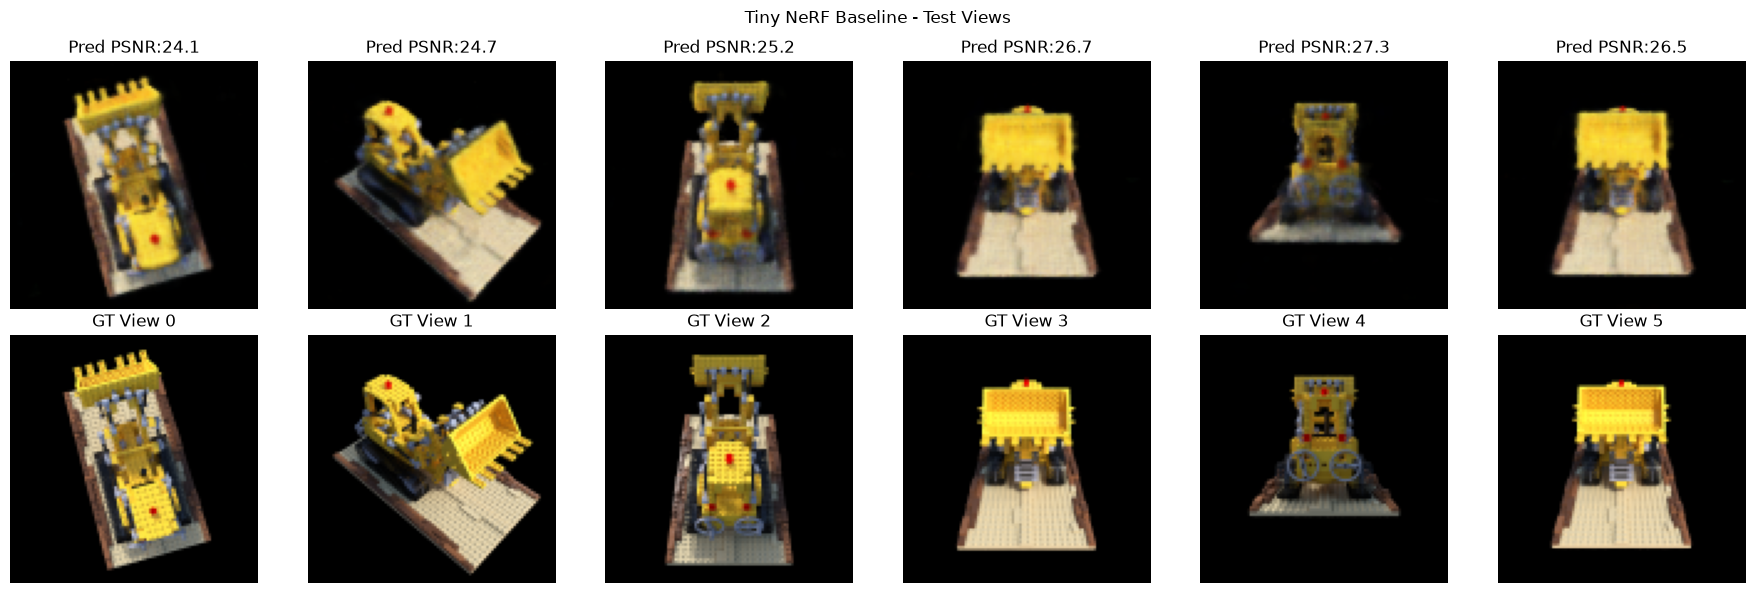

Baseline Mean Test PSNR: 25.73 ± 1.15 dB
Metrics saved to results/baseline_metrics.json


In [23]:
# Load best checkpoint
try:
    checkpoint = torch.load('weights/tiny_nerf_best.pth', map_location=device, weights_only=False)
except TypeError:
    checkpoint = torch.load('weights/tiny_nerf_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

near, far = CONFIG['near'], CONFIG['far']
N_samples = CONFIG['num_samples']
train_psnrs = checkpoint.get('train_psnrs', train_psnrs if 'train_psnrs' in locals() else [])
test_psnrs = checkpoint.get('test_psnrs', test_psnrs if 'test_psnrs' in locals() else [])
train_losses = checkpoint.get('train_losses', train_losses if 'train_losses' in locals() else [10.0 ** (-p / 10.0) for p in train_psnrs])
total_time = checkpoint.get('total_training_time', total_time if 'total_time' in locals() else 0.0)

# Full test evaluation
per_view_metrics = []
with torch.inference_mode():
    fig, axes = plt.subplots(2, len(test_images), figsize=(3*len(test_images), 6))
    for test_idx in range(len(test_images)):
        testimg = test_images[test_idx].to(device)
        testpose = test_poses[test_idx].to(device)
        rays_o, rays_d = get_rays(K, testpose, H, W)
        rgb = render_image_baseline(model, rays_o, rays_d, near=near, far=far, N_samples=N_samples, rand=False)
        test_mse = F.mse_loss(rgb, testimg).item()
        psnr = -10.0 * np.log10(test_mse)
        per_view_metrics.append({'view': test_idx, 'mse': test_mse, 'psnr': psnr})
        
        axes[0, test_idx].imshow(rgb.cpu().numpy().clip(0, 1))
        axes[0, test_idx].set_title(f'Pred PSNR:{psnr:.1f}')
        axes[0, test_idx].axis('off')
        axes[1, test_idx].imshow(testimg.cpu().numpy())
        axes[1, test_idx].set_title(f'GT View {test_idx}')
        axes[1, test_idx].axis('off')
    plt.suptitle('Tiny NeRF Baseline - Test Views')
    plt.tight_layout()
    plt.savefig('results/figures/baseline_test_views.png', dpi=150, bbox_inches='tight')
    plt.show()

mean_psnr = np.mean([m['psnr'] for m in per_view_metrics])
std_psnr = np.std([m['psnr'] for m in per_view_metrics])
print(f"Baseline Mean Test PSNR: {mean_psnr:.2f} ± {std_psnr:.2f} dB")

# Save metrics
metrics = {
    'per_view': per_view_metrics,
    'mean_psnr': float(mean_psnr),
    'std_psnr': float(std_psnr),
    'min_psnr': float(np.min([m['psnr'] for m in per_view_metrics])),
    'max_psnr': float(np.max([m['psnr'] for m in per_view_metrics])),
    'train_psnrs': [float(x) for x in train_psnrs],
    'test_psnrs': [float(x) for x in test_psnrs],
    'train_losses': [float(x) for x in train_losses],
    'total_training_time': float(total_time),
    'num_parameters': sum(p.numel() for p in model.parameters()),
    'config': CONFIG,
}
with open('results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print("Metrics saved to results/baseline_metrics.json")

## Training History Plot

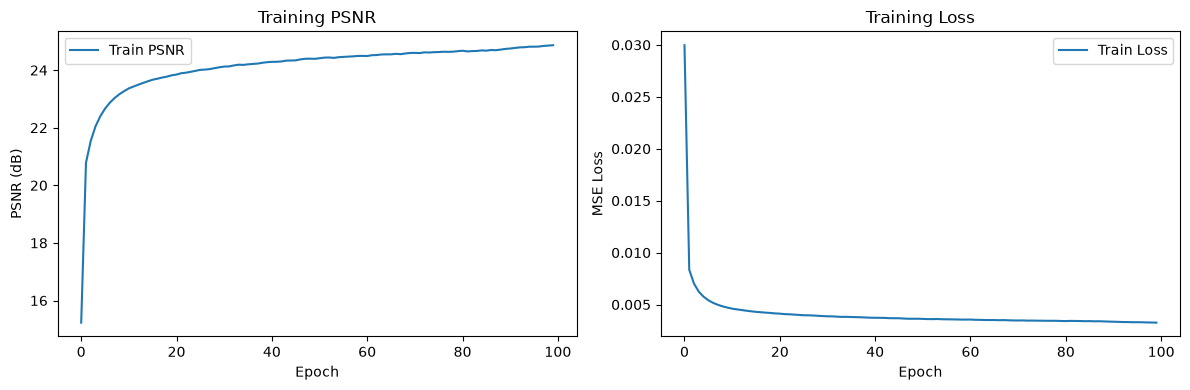

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
if 'train_psnrs' in locals() and len(train_psnrs) > 0:
    ax1.plot(train_psnrs, label='Train PSNR')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('PSNR (dB)'); ax1.legend(); ax1.set_title('Training PSNR')
if 'train_losses' in locals() and len(train_losses) > 0:
    ax2.plot(train_losses, label='Train Loss')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('MSE Loss'); ax2.legend(); ax2.set_title('Training Loss')
plt.tight_layout()
plt.savefig('results/figures/baseline_training_history.png', dpi=150, bbox_inches='tight')
plt.show()